# 🚀 Transformer: The Core of Modern AI

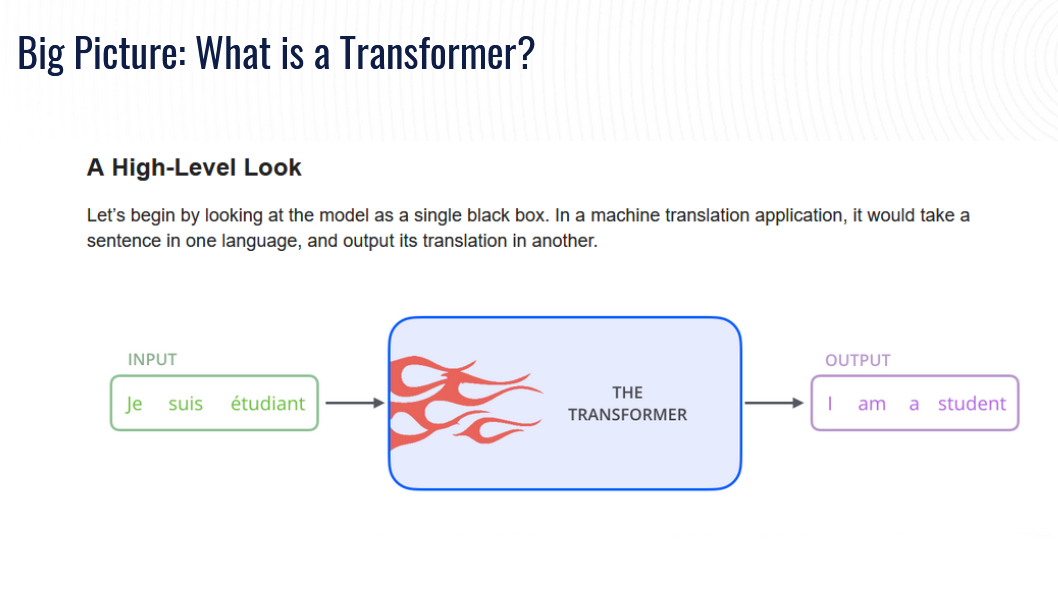

## Inside Transformers: How AI Like ChatGPT Works

## 📘 1. Introduction
The Transformer architecture, introduced in the paper "Attention is All You Need" (Vaswani et al., 2017), revolutionized sequence modeling by solving major issues found in earlier architectures like RNNs and LSTMs. Transformers made possible efficient training, long-range dependency capture, and true parallelization — leading to breakthroughs in language understanding and generation.

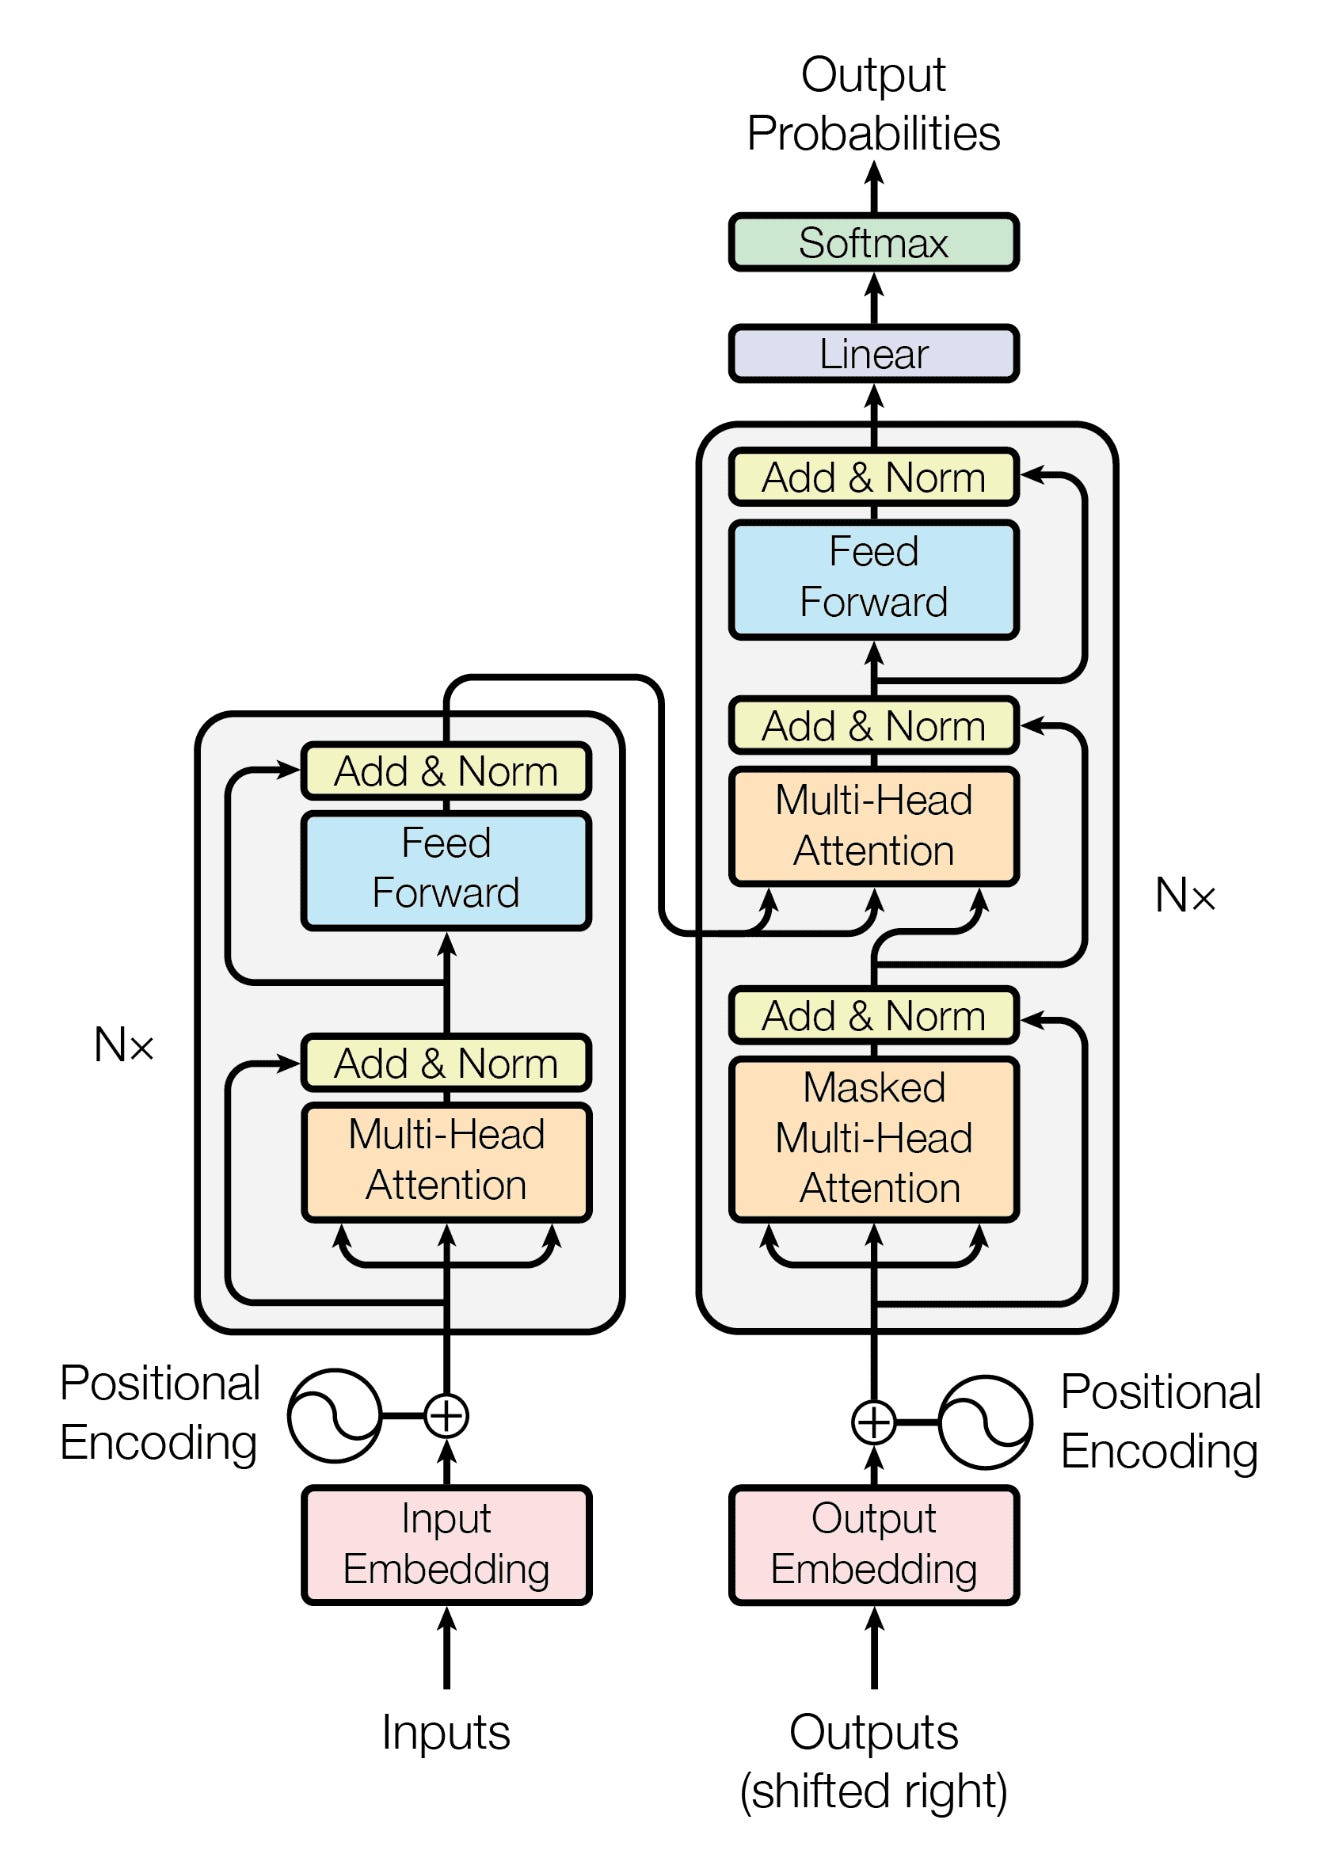

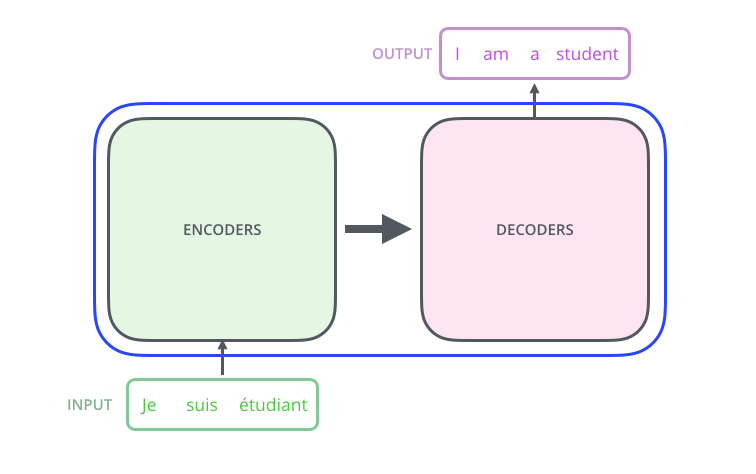

In [ ]:
the cat sat on the mat

## 🔁 2. Pre-Transformer Models: RNN, LSTM

### RNN
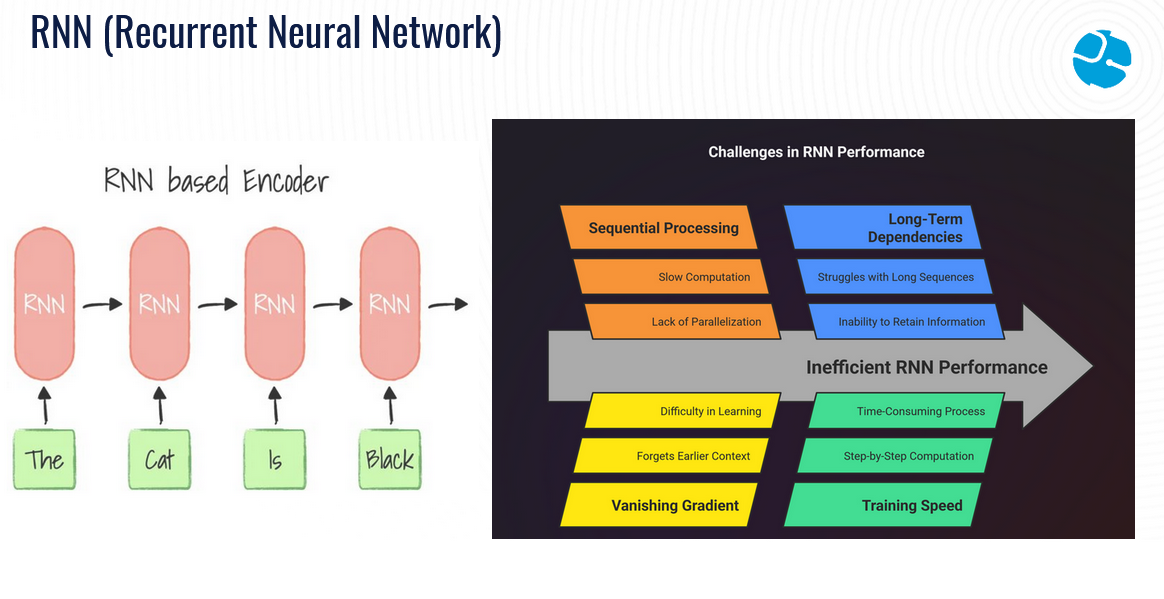
### 🧠 Problems with RNNs:
- Cannot parallelize computations (sequence dependent)
- Vanishing gradient problem
- Poor at capturing long-term dependencies

In [ ]:
the cat sat on the mat

     0.6 0.9   0.1   0.6

### 🧠 LSTM: Improvement over RNNs
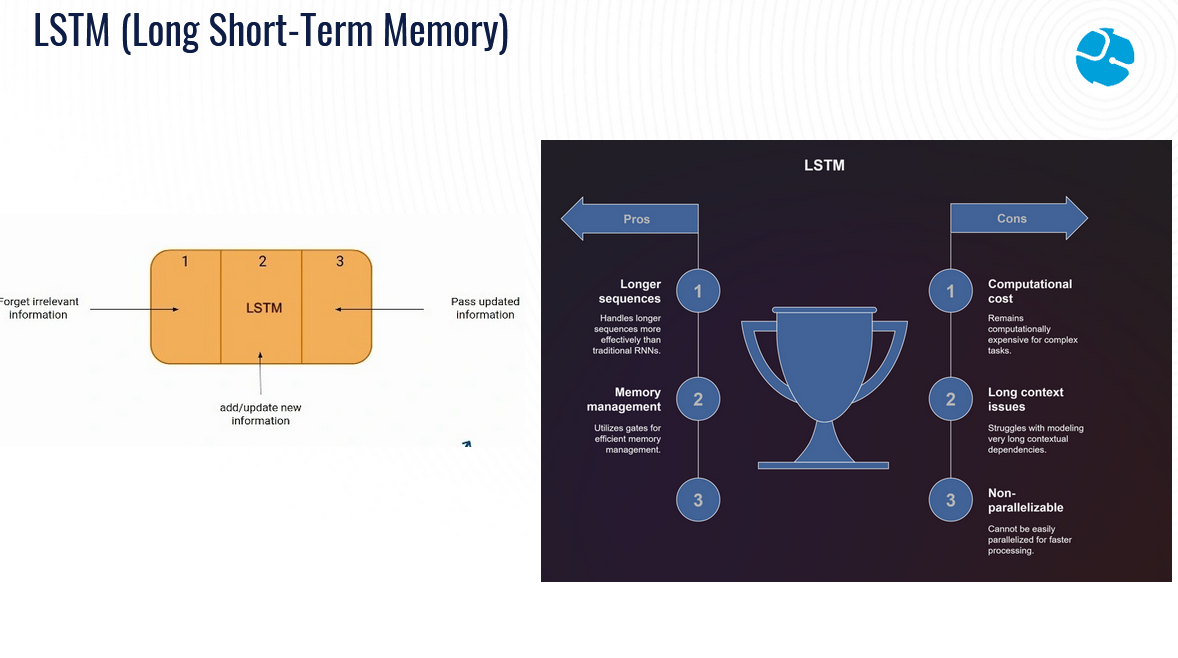
LSTM adds gating mechanisms to better handle long-range dependencies.

Still, LSTMs require sequential processing and are hard to scale.

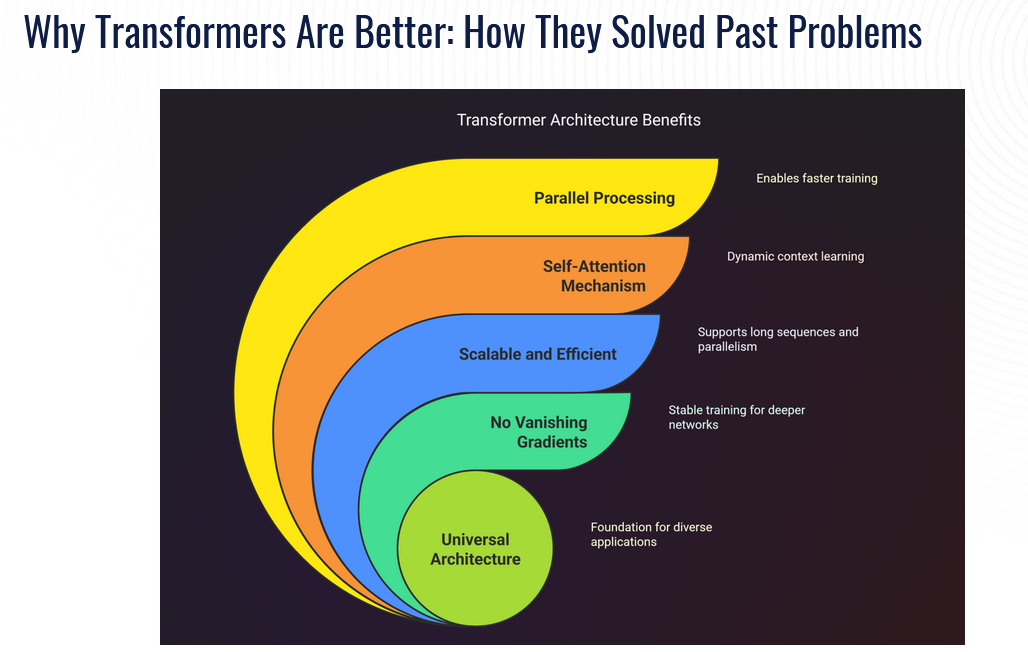

In [ ]:
the cat sat on the mat
0    1   2   3  4   5

## ⚙️ 3. The Transformer Architecture
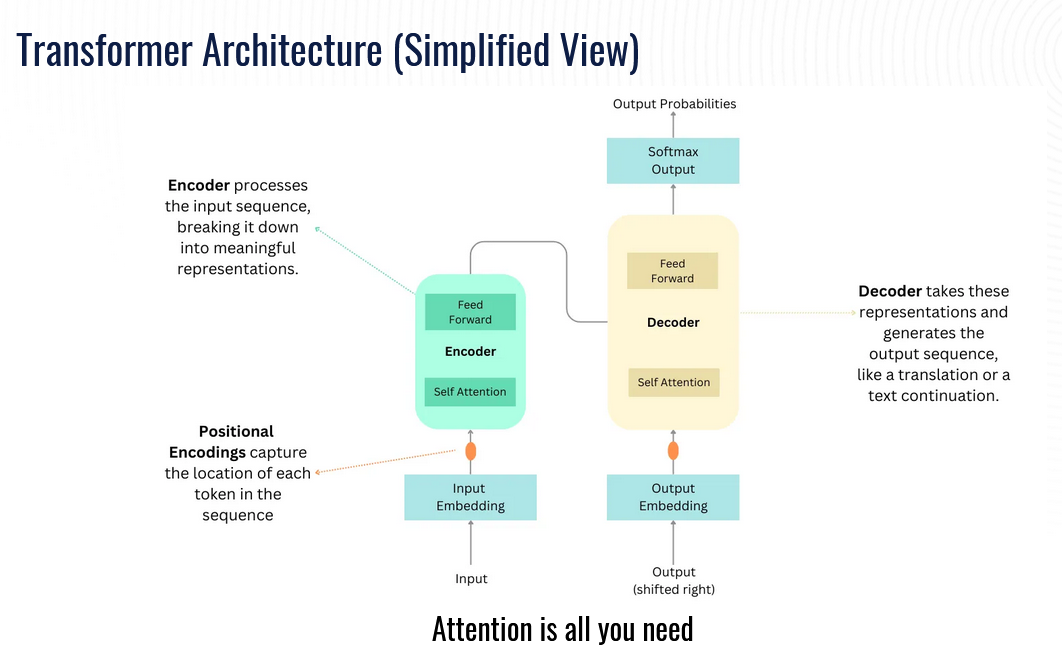


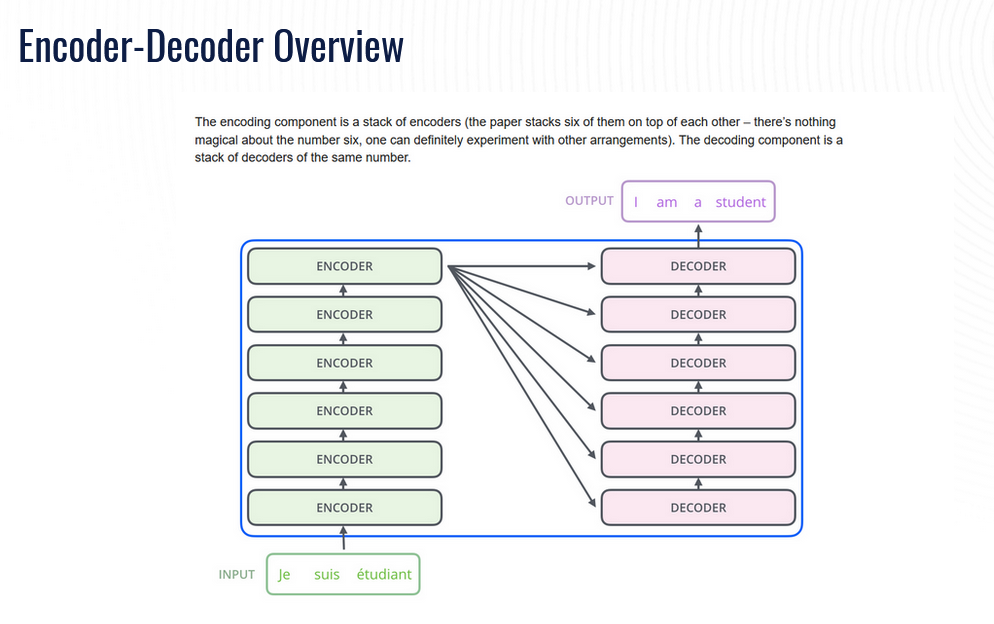

### 🔍 Key Ideas:
- Self-Attention Mechanism
- Positional Encoding
- Fully Feedforward, enabling parallel training

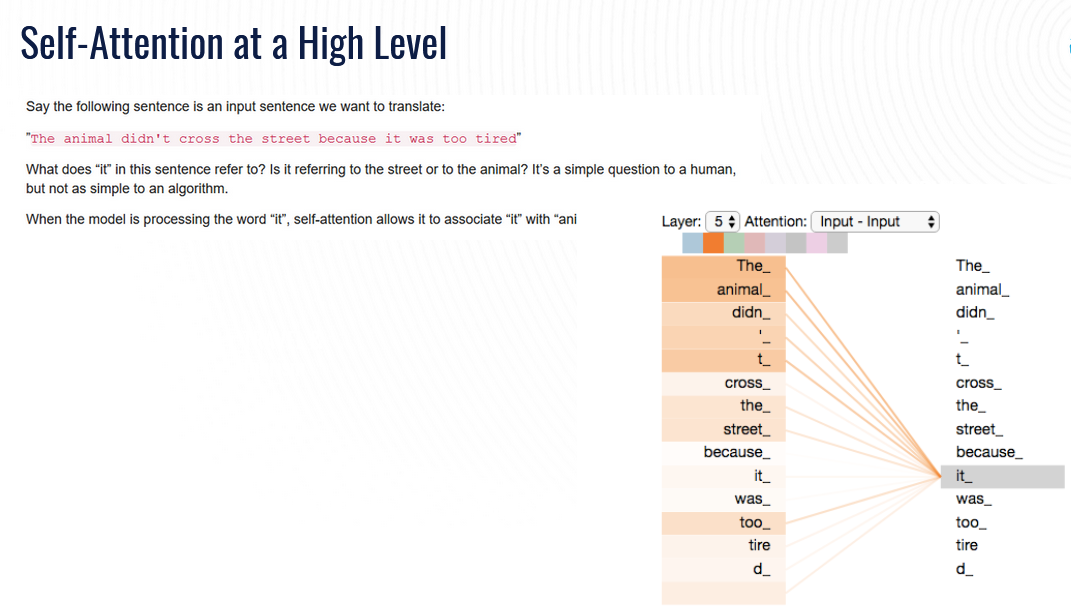

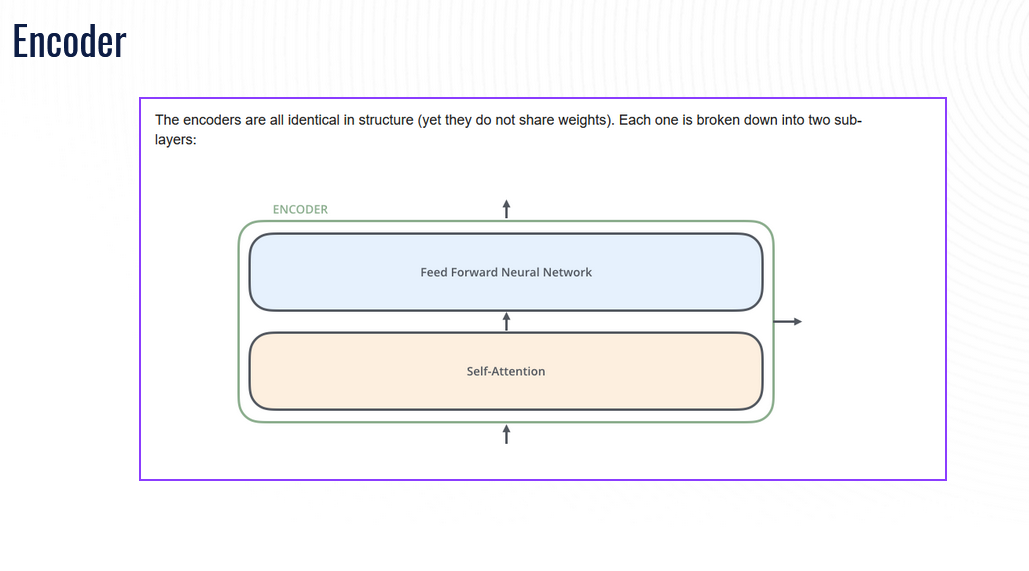

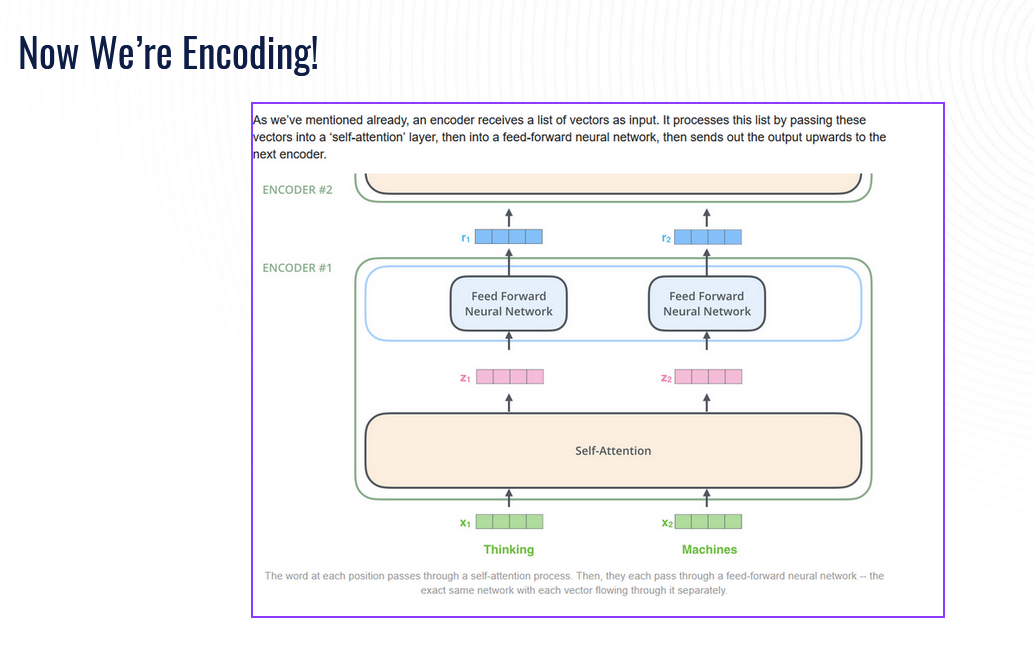

the cat sat on the mat

### 🔁 Self-Attention
Self-attention allows each token to attend to all other tokens in the sequence:

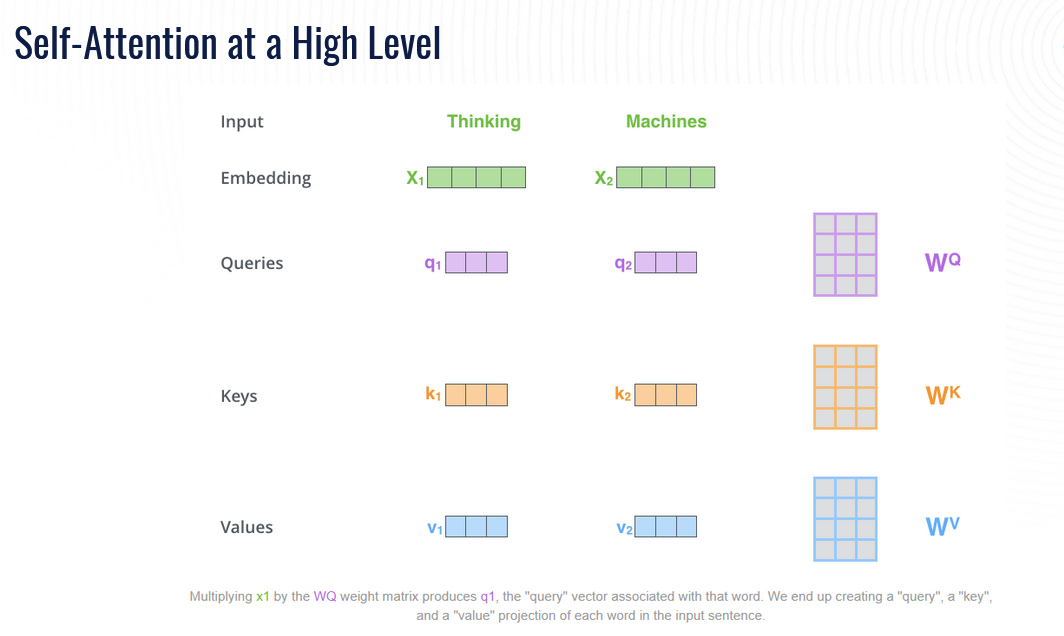

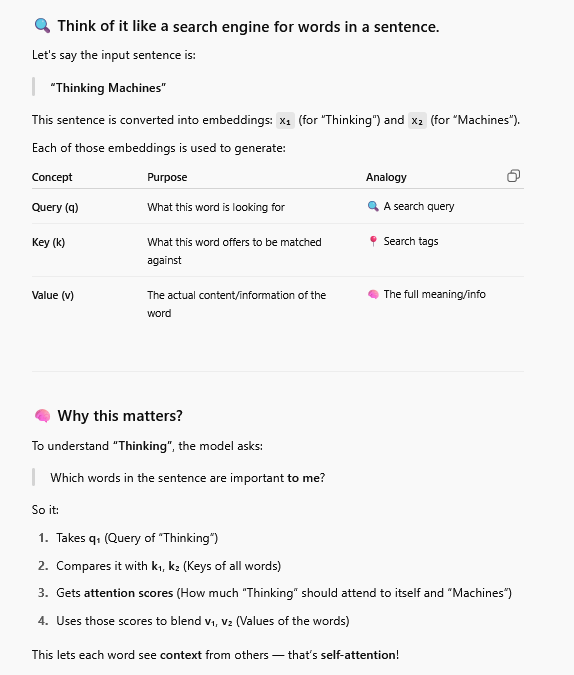

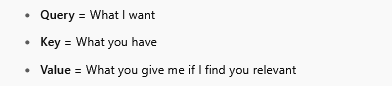

In [ ]:
import torch.nn.functional as F

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / d_k**0.5
    attn_weights = F.softmax(scores, dim=-1)
    return attn_weights @ V

### 🔧 Real Example: Using HuggingFace's Transformer Model for Summarization

In [ ]:
llama

In [ ]:
from transformers import pipeline
summarizer = pipeline("summarization") /question-answering / text-generation
text = """
The Transformer architecture has fundamentally transformed the field of artificial intelligence, particularly in natural language processing.
Unlike earlier models such as RNNs or LSTMs that process data sequentially, Transformers introduce a mechanism called self-attention,
which allows the model to consider all parts of the input simultaneously. This innovation eliminates the bottleneck of sequential processing
and enables the model to learn long-range dependencies more effectively. As a result, Transformers serve as the foundation for some of the
most advanced AI models today, including BERT for language understanding and GPT for language generation. Their versatility and scalability
have led to breakthroughs in tasks like machine translation, summarization, question answering, and even code generation.
"""
summary = summarizer(text, max_length=50, min_length=10)
print(summary[0]['summary_text'])

No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 and revision a4f8f3e (https://huggingface.co/sshleifer/distilbart-cnn-12-6).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


 Transformer architecture has fundamentally transformed the field of artificial intelligence, particularly in natural language processing . Transformers introduce a mechanism called self-attention, which allows the model to consider all parts of the input simultaneously . Transformers serve as the foundation for


## 📚 4. BERT (2018): Bidirectional Encoder Representations
- Transformer **Encoder** only
- Trained on Masked Language Modeling (MLM) + Next Sentence Prediction (NSP)
- Great for understanding tasks

In [ ]:
i am eating rice

In [ ]:
Takes

Sentence 1
Sentence 2

### 🔍 Example: Use BERT for Sentence Embedding

In [ ]:
from transformers import BertTokenizer, BertModel

model = BertModel.from_pretrained("bert-base-uncased")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
inputs = tokenizer("Transformers are amazing!", return_tensors="pt")
outputs = model(**inputs)
cls_embedding = outputs.last_hidden_state[:, 0, :]  # [CLS] token embedding
print(cls_embedding.shape)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

torch.Size([1, 768])


## 🤖 5. GPT: Generative Pretrained Transformers
- Transformer **Decoder** architecture
- Autoregressive: Trained to predict the next token
- Causal (masked) attention: token can only see the previous ones

### 📈 Evolution:
- **GPT-1 (2018)**: 117M parameters
- **GPT-2 (2019)**: 1.5B parameters
- **GPT-3 (2020)**: 175B parameters
- **GPT-4 (2023)**: Multimodal, few-shot learning

### 🔍 Example: Generate Text Using GPT-2

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

model = GPT2LMHeadModel.from_pretrained("gpt2")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
inputs = tokenizer("Once upon a time", return_tensors="pt")
outputs = model.generate(inputs['input_ids'], max_length=50)
print(tokenizer.decode(outputs[0]))

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Once upon a time, the world was a place of great beauty and great danger. The world was a place of great danger, and the world was a place of great danger. The world was a place of great danger, and the world was a


## 🛠️ 6. Real-World Tasks These Models Can Do
### 🔡 Language Understanding (BERT-style models):
- Sentiment Analysis
- Text Classification
- Named Entity Recognition (NER)
- Question Answering

In [ ]:
contextual meaning vector

In [ ]:
from transformers import pipeline
qa = pipeline("question-answering")
qa({
    'context': "Transformers use self-attention to process sequences.",
    'question': "What do transformers use?"
})

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu
/usr/local/lib/python3.11/dist-packages/transformers/pipelines/question_answering.py:390: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(


{'score': 0.9051019549369812,
 'start': 17,
 'end': 31,
 'answer': 'self-attention'}

### ✍️ Language Generation (GPT-style models):
- Text Completion
- Email Drafting
- Creative Writing
- Code Generation (e.g., Copilot)

### 🔁 Seq2Seq Models (T5, BART):
- Translation
- Summarization
- Paraphrasing

In [ ]:
from transformers import pipeline
translator = pipeline("translation_en_to_fr")
translator("Transformers are the backbone of modern AI.")

No model was supplied, defaulted to google-t5/t5-base and revision a9723ea (https://huggingface.co/google-t5/t5-base).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


[{'translation_text': "Les transformateurs sont l'épine dorsale de l'AI moderne."}]

## 🧩 Attention Visualization (Optional)

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


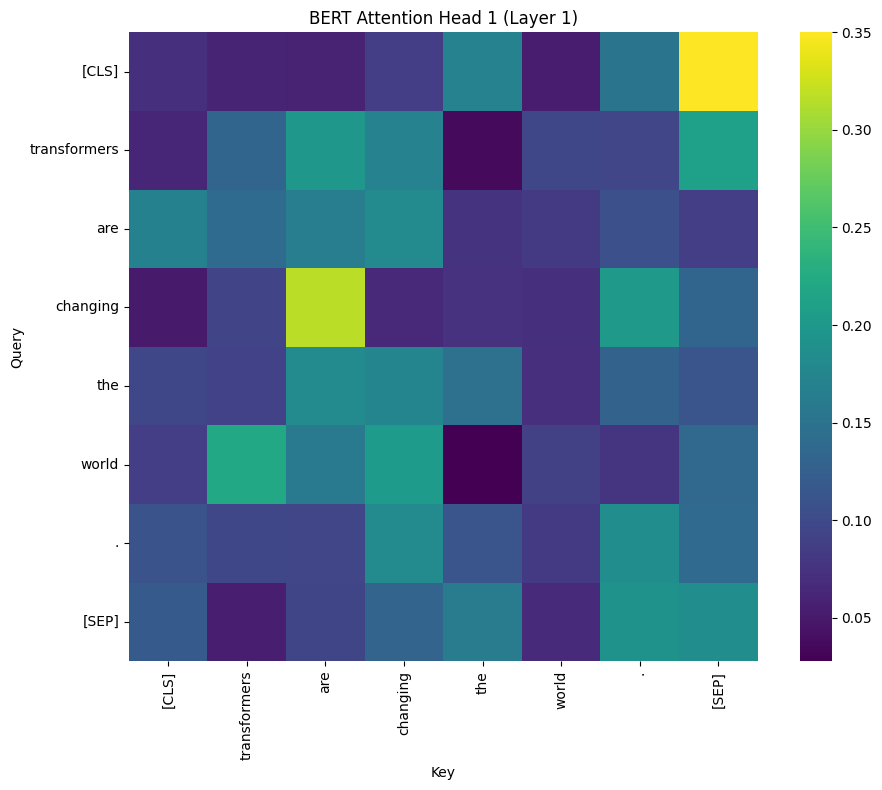

In [ ]:
# Load BERT and get attention from a real sentence
model = BertModel.from_pretrained("bert-base-uncased", output_attentions=True)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
inputs = tokenizer("Transformers are changing the world.", return_tensors="pt")
outputs = model(**inputs)

# Extract attention weights from the first layer, first head
attentions = outputs.attentions[0]  # shape: (batch_size, num_heads, seq_len, seq_len)
attn_matrix = attentions[0, 0].detach().numpy()  # first head of first layer

# Token labels
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(attn_matrix, xticklabels=tokens, yticklabels=tokens, cmap='viridis', square=True)
plt.title("BERT Attention Head 1 (Layer 1)")
plt.xlabel("Key")
plt.ylabel("Query")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 📌 Summary Table
| Model     | Type              | Key Use Case                   |
|-----------|-------------------|--------------------------------|
| RNN       | Recurrent         | Simple sequential tasks        |
| LSTM      | Recurrent (memory)| Long-term dependencies         |
| Transformer| Encoder-Decoder   | Language translation, summarization |
| BERT      | Encoder           | Understanding tasks (QA, NER) |
| GPT       | Decoder           | Text generation                |
| T5/BART   | Encoder-Decoder   | Seq2seq (translation, summary) |